# 1. Análisis Exploratorio de Datos (EDA)
## Proyecto: Clasificación de Enfermedades en Hoja de Maíz

---

## Objetivo

Comprender la composición del dataset consolidado en `data/clean/`, identificar problemas potenciales (desbalance, sesgos de captura, duplicados, calidad de imagen) y justificar las decisiones de preprocesamiento y entrenamiento del modelo.

---

## 1.1 Documentación general del dataset

### Ficha técnica

| Campo | Valor |
|---|---|
| **Total de imágenes** | 31 622 |
| **Número de clases** | 9 |
| **Directorio base** | `data/clean/` |
| **Tamaño total en disco** | ~14.3 GB |

---

### Descripción de clases

#### Enfermedades foliares

| Clase | Nombre científico | Total | Lab | Real |
|---|---|---:|---:|---:|
| `common_rust` | *Puccinia sorghi* | 2 256 | 2 150 | 106 |
| `northern_corn_leaf_blight` | *Exserohilum turcicum* | 6 830 | 888 | 5 942 |
| `gray_leaf_spot` | *Cercospora zeae-maydis* | 1 119 | 513 | 606 |
| `healthy` | - | 8 744 | 0 | 8 744 |
| `lethal_necrosis` | MLN (*MCMV* + *SCMV*) | 6 415 | 0 | 6 415 |

#### Plagas

| Clase | Nombre científico | Total | Lab | Real |
|---|---|---:|---:|---:|
| `fall_armyworm` | *Spodoptera frugiperda* | 4 857 | 0 | 4 857 |

#### Deficiencias nutricionales

| Clase | Total | Lab | Real |
|---|---:|---:|---:|
| `nitrogen_deficiency` | 523 | 0 | 523 |
| `phosphorus_deficiency` | 612 | 0 | 612 |
| `potassium_deficiency` | 266 | 0 | 266 |

---

### Procedencia de las imágenes

Las imágenes provienen de **datasets públicos**. No se incluyen capturas propias. Los datasets de origen son:

| Identificador | Dataset original | Fuente |
|---|---|---|
| `corn_leaf_roboflow` | corn-leaf-roboflow | Roboflow Universe |
| `cropdg` | cropdg-unified-multidomain | CropDG (PlantVillage subset) |
| `maize_africa` | maize-beans-tomatoes-africa | Kaggle |
| `maize_desease` | maize-diseases | Kaggle |
| `maize_field` | maize-in-field-dataset | Kaggle |
| `maize_nutrient` | maize-nutrient-deficiency | Kaggle |

> **Descartados:** `corn-leaf-diseases` (imágenes augmentadas sin originales) y `multicrop-disease` (mezcla destructiva de entornos y preprocesados sin estructura).

---

### Condiciones de captura

| Contexto | Descripción |
|---|---|
| **`lab`** | Fondo uniforme (negro/blanco/gris), entorno controlado, iluminación artificial, distancia corta y constante. Típico de PlantVillage. |
| **`real`** | Campo abierto, fondo natural variable, iluminación solar (variable), diversidad de distancias y ángulos. |

- **Resolución:** heterogénea. Las imágenes de `corn_leaf_roboflow` ya vienen redimensionadas a **640 × 640 px** (Roboflow). El resto conserva resolución original.
- **Formato:** predominantemente JPEG/JPG, algunos PNG.
- **Naming convention:** `<clase>_<origen>_<tipo>_<correlativo>.<ext>`

In [1]:
import importlib
import subprocess
import sys

REQUIRED = {
    "cv2":          "opencv-python-headless",
    "skimage":      "scikit-image",
    "sklearn":      "scikit-learn",
    "PIL":          "Pillow",
    "matplotlib":   "matplotlib",
    "seaborn":      "seaborn",
    "pandas":       "pandas",
    "numpy":        "numpy",
    "tqdm":         "tqdm",
    "dotenv":       "python-dotenv",
    "yaml":         "PyYAML",
    "gdown":        "gdown",
}

missing = {pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None}

if missing:
    print(f"Instalando paquetes faltantes: {', '.join(sorted(missing))}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *sorted(missing)])
    print("Instalación completada. Si hay errores de importación más abajo, reinicia el kernel.")
else:
    print("Todas las dependencias están disponibles.")


Todas las dependencias están disponibles.


In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

GDRIVE_FILE_ID = "155qQSefER_2Jhdh6DZY9kKzv3wVKtcg9"

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / ".env").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        PROJECT_ROOT = None
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT:
    load_dotenv(PROJECT_ROOT / ".env", override=True)

_ENV_ROOT = os.getenv("DATASET_ROOT")

if _ENV_ROOT and Path(_ENV_ROOT).exists():
    DATASET_ROOT = Path(_ENV_ROOT)
    print(f"Entorno: servidor/local (DATASET_ROOT={DATASET_ROOT})")

else:
    DATASET_ROOT = Path("/content/corn-leaf-diseases")

    if not (DATASET_ROOT / "clean").exists():
        import gdown
        import zipfile

        ZIP = Path("/content/corn-leaf-diseases-clean.zip")

        if not ZIP.exists():
            print("Descargando dataset (~14 GB)...")
            gdown.download(
                id=GDRIVE_FILE_ID,
                output=str(ZIP),
                quiet=False
            )

        print("Descomprimiendo...")
        with zipfile.ZipFile(ZIP, "r") as zf:
            zf.extractall("/content/corn-leaf-diseases")

        ZIP.unlink()
        print("Listo.")

    PROJECT_ROOT = Path("/content/corn-leaf-desease-project")
    print("Entorno: Google Colab")

DATA_DIR = DATASET_ROOT / "clean"

if not Path(DATA_DIR).exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_DIR}\n"
        "Verifica que DATASET_ROOT en .env apunte al dataset, o que el archivo de Drive sea accesible públicamente."
    )

TMP_DIR = (PROJECT_ROOT / "tmp") if PROJECT_ROOT else Path("tmp")
TMP_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Clean dir:    {DATA_DIR}")
print(f"Figuras:      {TMP_DIR}")

class_names = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Clases encontradas ({len(class_names)}): {class_names}")

sns.set_theme(style="whitegrid")

Entorno: servidor/local (DATASET_ROOT=/mnt/datasets/data/corn-leaf-diseases)
Dataset root: /mnt/datasets/data/corn-leaf-diseases
Clean dir:    /mnt/datasets/data/corn-leaf-diseases/clean
Figuras:      /mnt/datasets/users/david/doctor-maiz/corn-leaf-desease-project/tmp
Clases encontradas (9): ['lethal_necrosis', 'nitrogen_deficiency', 'healthy', 'common_rust', 'northern_corn_leaf_blight', 'phosphorus_deficiency', 'gray_leaf_spot', 'potassium_deficiency', 'fall_armyworm']


---

## 1.2 Análisis de distribución de clases

Identificar si el dataset presenta un desbalance significativo es el primer paso antes de diseñar el pipeline de entrenamiento. Un desbalance severo puede hacer que el modelo se sesgue hacia la clase mayoritaria (ej. `healthy`), ignorando las enfermedades menos representadas.

Para mitigar este problema se utilizan técnicas como **`class_weights`** (penalizar más los errores en clases minoritarias) o muestreo ponderado (`WeightedRandomSampler`), ambas dependientes de conocer la distribución real de los datos.

Adicionalmente se desglosa el conteo entre imágenes de **laboratorio** (`lab/`) e imágenes de **campo** (`real/`), dado que ambos entornos de captura representan distribuciones visuales muy distintas y su proporción afecta directamente el riesgo de sesgo por dominio.

Total de imágenes: 31,622

                    clase  lab  real  total  porcentaje
                  healthy    0  8744   8744       27.65
northern_corn_leaf_blight  888  5942   6830       21.60
          lethal_necrosis    0  6415   6415       20.29
            fall_armyworm    0  4857   4857       15.36
              common_rust 2150   106   2256        7.13
           gray_leaf_spot  513   606   1119        3.54
    phosphorus_deficiency    0   612    612        1.94
      nitrogen_deficiency    0   523    523        1.65
     potassium_deficiency    0   266    266        0.84


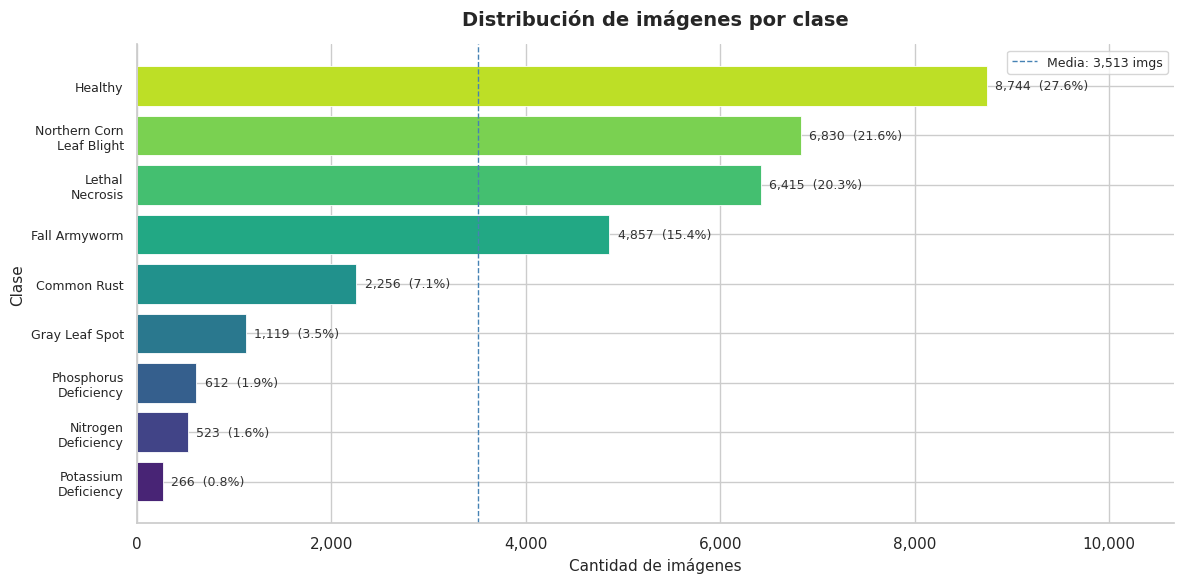

In [3]:
from pathlib import Path
import matplotlib.ticker as mticker
import numpy as np

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(directory: Path) -> int:
    return sum(1 for f in directory.rglob("*") if f.suffix.lower() in IMG_EXTS)

CLEAN_DIR = Path(DATA_DIR)

records = []
for class_dir in sorted(CLEAN_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    lab_dir  = class_dir / "lab"
    real_dir = class_dir / "real"
    lab_count  = count_images(lab_dir)  if lab_dir.is_dir()  else 0
    real_count = count_images(real_dir) if real_dir.is_dir() else 0
    records.append({
        "clase":   class_dir.name,
        "lab":     lab_count,
        "real":    real_count,
        "total":   lab_count + real_count,
    })

df = pd.DataFrame(records).sort_values("total", ascending=False).reset_index(drop=True)
total_imgs = df["total"].sum()
df["porcentaje"] = (df["total"] / total_imgs * 100).round(2)

print(f"Total de imágenes: {total_imgs:,}\n")
print(df.to_string(index=False))

LABEL_MAP = {
    "healthy":                    "Healthy",
    "northern_corn_leaf_blight":  "Northern Corn\nLeaf Blight",
    "lethal_necrosis":            "Lethal\nNecrosis",
    "fall_armyworm":              "Fall Armyworm",
    "common_rust":                "Common Rust",
    "gray_leaf_spot":             "Gray Leaf Spot",
    "phosphorus_deficiency":      "Phosphorus\nDeficiency",
    "nitrogen_deficiency":        "Nitrogen\nDeficiency",
    "potassium_deficiency":       "Potassium\nDeficiency",
}
df["label"] = df["clase"].map(LABEL_MAP).fillna(df["clase"])

# Ordenar de mayor a menor para el gráfico horizontal
df_plot = df.sort_values("total", ascending=True).reset_index(drop=True)

palette = sns.color_palette("viridis", len(df_plot))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_plot["label"], df_plot["total"], color=palette, edgecolor="white", linewidth=0.6)

for bar, total, pct in zip(bars, df_plot["total"], df_plot["porcentaje"]):
    ax.text(
        bar.get_width() + df_plot["total"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{total:,}  ({pct:.1f}%)",
        va="center", ha="left", fontsize=9, color="#333333",
    )

ax.axvline(total_imgs / len(df_plot), color="steelblue", linestyle="--", linewidth=1,
           label=f"Media: {total_imgs // len(df_plot):,} imgs")
ax.set_title("Distribución de imágenes por clase", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Cantidad de imágenes", fontsize=11)
ax.set_ylabel("Clase", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, df_plot["total"].max() * 1.22)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(TMP_DIR / "eda_01_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 1.3 Análisis de origen de las imágenes (lab vs real)

La procedencia de la imagen introduce un riesgo de *atajos de aprendizaje*: si una enfermedad tiene el 95 % de sus imágenes tomadas en laboratorio con fondo blanco uniforme, la red neuronal puede aprender a identificar ese fondo en lugar del patógeno real.

Este análisis cuantifica la proporción `lab / real` por clase y detecta cuáles tienen un sesgo de dominio crítico.

Proporción lab / real por clase:

                     label  lab  pct_lab  real  pct_real  total
                   Healthy    0      0.0  8744     100.0   8744
Northern Corn\nLeaf Blight  888     13.0  5942      87.0   6830
          Lethal\nNecrosis    0      0.0  6415     100.0   6415
             Fall Armyworm    0      0.0  4857     100.0   4857
               Common Rust 2150     95.3   106       4.7   2256
            Gray Leaf Spot  513     45.8   606      54.2   1119
    Phosphorus\nDeficiency    0      0.0   612     100.0    612
      Nitrogen\nDeficiency    0      0.0   523     100.0    523
     Potassium\nDeficiency    0      0.0   266     100.0    266


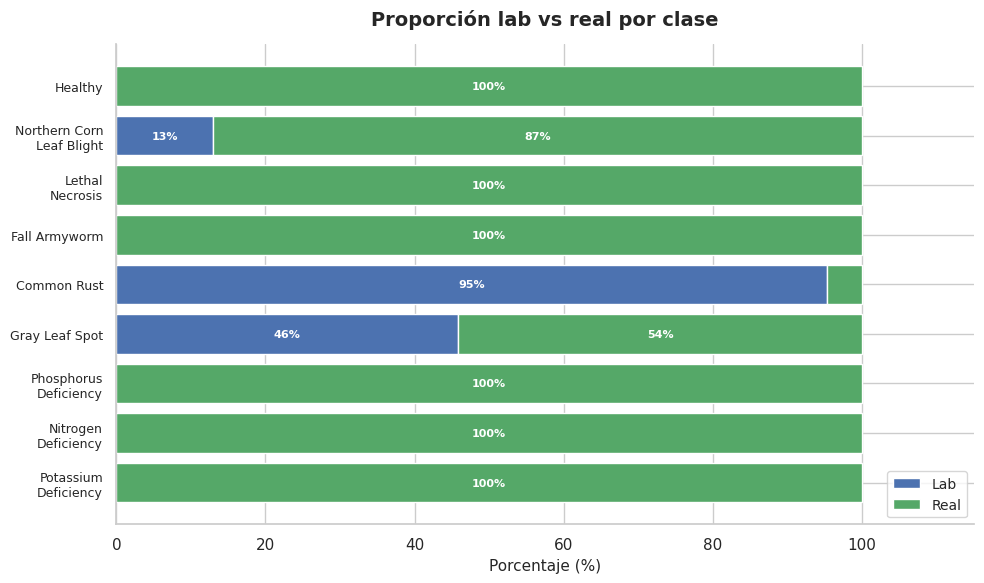

In [4]:
df_origen = df[["label", "lab", "real", "total"]].copy()
df_origen["pct_lab"]  = (df_origen["lab"]  / df_origen["total"] * 100).round(1)
df_origen["pct_real"] = (df_origen["real"] / df_origen["total"] * 100).round(1)

print("Proporción lab / real por clase:\n")
print(df_origen[["label", "lab", "pct_lab", "real", "pct_real", "total"]].to_string(index=False))

# Ordenar de mayor a menor total para consistencia con 1.2
df_origen_sorted = df_origen.sort_values("total", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

lab_vals  = df_origen_sorted["pct_lab"].values
real_vals = df_origen_sorted["pct_real"].values
labels    = df_origen_sorted["label"].values

bars_lab  = ax.barh(labels, lab_vals,  color="#4C72B0", edgecolor="white", label="Lab")
bars_real = ax.barh(labels, real_vals, left=lab_vals, color="#55A868", edgecolor="white", label="Real")

for bar, val in zip(bars_lab, lab_vals):
    if val > 5:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", ha="center", fontsize=8, color="white", fontweight="bold",
        )

for bar, val in zip(bars_real, real_vals):
    if val > 5:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", ha="center", fontsize=8, color="white", fontweight="bold",
        )

ax.set_xlabel("Porcentaje (%)", fontsize=11)
ax.set_title("Proporción lab vs real por clase", fontsize=14, fontweight="bold", pad=14)
ax.set_xlim(0, 115)
ax.tick_params(axis="y", labelsize=9)
ax.legend(fontsize=10, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(TMP_DIR / "eda_02_lab_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 1.4 Análisis de resolución y dimensiones

Las redes neuronales convolucionales requieren tensores de entrada con dimensiones fijas (p.ej. 224×224 px para MobileNetV3). Conocer las dimensiones originales ayuda a entender cuánta información se perderá o distorsionará durante el redimensionamiento (*resizing*), y si existen imágenes con proporciones o tamaños anómalos.

Se usa un **muestreo estratificado** de hasta 400 imágenes por clase para acelerar el análisis sin perder representatividad.

/mnt/datasets/users/david/doctor-maiz/corn-leaf-desease-project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total de imágenes encontradas: 31,622


Muestra para análisis de dimensiones: 3,466 imágenes



Leyendo dimensiones:   0%|          | 0/3466 [00:00<?, ?it/s]


Leyendo dimensiones:   2%|▏         | 54/3466 [00:00<00:06, 530.64it/s]

...


Leyendo dimensiones:  96%|█████████▌| 3326/3466 [00:06<00:00, 576.62it/s]


Leyendo dimensiones:  98%|█████████▊| 3395/3466 [00:06<00:00, 607.37it/s]


Leyendo dimensiones: 100%|█████████▉| 3457/3466 [00:06<00:00, 476.28it/s]


Leyendo dimensiones: 100%|██████████| 3466/3466 [00:06<00:00, 539.34it/s]

        width  height     mpx  aspect
count  3466.0  3466.0  3466.0  3466.0
mean    907.5   861.0     1.6     1.0
std    1020.5   821.8     3.6     0.3
min      54.0    54.0     0.0     0.3
25%     306.8   307.0     0.1     1.0
50%     640.0   640.0     0.4     1.0
75%     768.0  1024.0     0.8     1.0
max    5184.0  5184.0    20.2     4.1


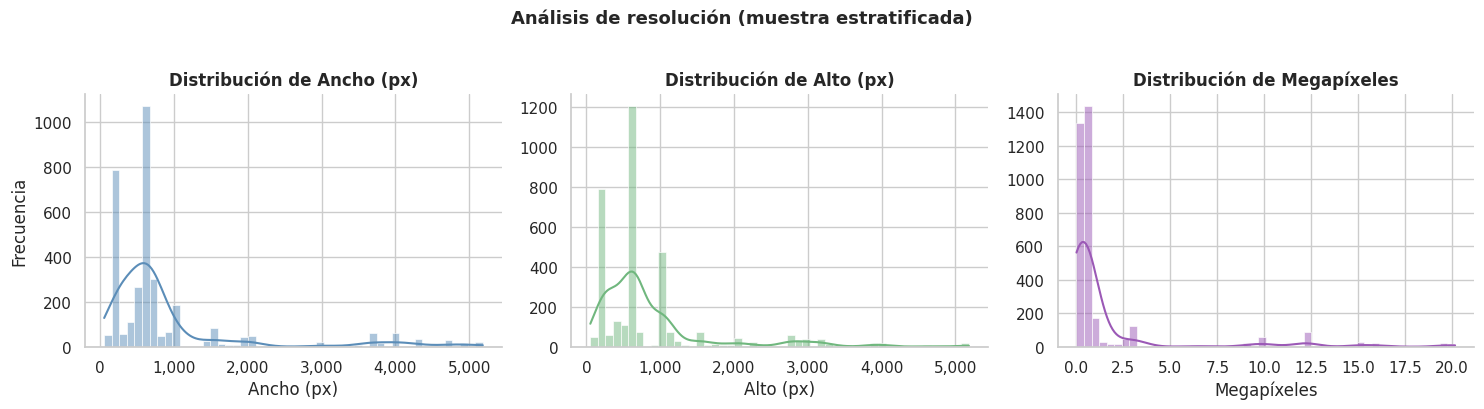


Ancho  - min: 54  max: 5,184  mediana: 640
Alto   - min: 54  max: 5,184  mediana: 640
Mpx    - min: 0.003  max: 20.155  mediana: 0.410
Aspect - min: 0.34  max: 4.11  mediana: 1.00


In [ ]:
from PIL import Image
import random
from tqdm.auto import tqdm

all_images = [p for p in CLEAN_DIR.rglob("*") if p.suffix.lower() in IMG_EXTS]
print(f"Total de imágenes encontradas: {len(all_images):,}")

# Muestreo estratificado: hasta 400 por clase
SAMPLE_PER_CLASS = 400
sampled = []
for class_dir in CLEAN_DIR.iterdir():
    if not class_dir.is_dir():
        continue
    imgs = [p for p in class_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
    if len(imgs) > SAMPLE_PER_CLASS:
        imgs = random.sample(imgs, SAMPLE_PER_CLASS)
    sampled.extend(imgs)

print(f"Muestra para análisis de dimensiones: {len(sampled):,} imágenes")

dim_records = []
errors = []
for path in tqdm(sampled, desc="Leyendo dimensiones"):
    try:
        with Image.open(path) as img:
            w, h = img.size
        rel = path.relative_to(CLEAN_DIR).parts
        clase = rel[0]
        tipo  = rel[1] if len(rel) > 1 else "?"
        dim_records.append({
            "clase":  clase,
            "tipo":   tipo,
            "width":  w,
            "height": h,
            "mpx":    round(w * h / 1_000_000, 3),
            "aspect": round(w / h, 3),
        })
    except Exception as e:
        errors.append((str(path), str(e)))

df_dim = pd.DataFrame(dim_records)
if errors:
    print(f"Errores al leer: {len(errors)}")
print(df_dim.describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_dim["width"],  bins=50, color="#5B8DB8", kde=True, ax=axes[0])
axes[0].set_title("Distribución de Ancho (px)", fontweight="bold")
axes[0].set_xlabel("Ancho (px)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

sns.histplot(df_dim["height"], bins=50, color="#70B77E", kde=True, ax=axes[1])
axes[1].set_title("Distribución de Alto (px)", fontweight="bold")
axes[1].set_xlabel("Alto (px)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

sns.histplot(df_dim["mpx"], bins=50, color="#9B59B6", kde=True, ax=axes[2])
axes[2].set_title("Distribución de Megapíxeles", fontweight="bold")
axes[2].set_xlabel("Megapíxeles")
axes[2].set_ylabel("")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Análisis de resolución (muestra estratificada)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(TMP_DIR / "eda_03_resoluciones.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAncho  - min: {df_dim['width'].min():,}  max: {df_dim['width'].max():,}  mediana: {df_dim['width'].median():,.0f}")
print(f"Alto   - min: {df_dim['height'].min():,}  max: {df_dim['height'].max():,}  mediana: {df_dim['height'].median():,.0f}")
print(f"Mpx    - min: {df_dim['mpx'].min():.3f}  max: {df_dim['mpx'].max():.3f}  mediana: {df_dim['mpx'].median():.3f}")
print(f"Aspect - min: {df_dim['aspect'].min():.2f}  max: {df_dim['aspect'].max():.2f}  mediana: {df_dim['aspect'].median():.2f}")

---

## 1.5 Análisis de calidad de imagen

Se evalúan tres métricas automáticas sobre la muestra estratificada generada en la sección anterior:

- **Desenfoque:** varianza del Laplaciano sobre la versión en escala de grises. Valores bajos (< 100) indican falta de bordes detectables - imagen borrosa.
- **Subexposición:** brillo medio (escala de grises) < 40 → imagen muy oscura / subexpuesta.
- **Sobreexposición:** brillo medio > 230 → imagen muy clara / saturada.

Estas métricas no son absolutas (una imagen de fondo negro puede tener brillo bajo siendo perfectamente válida), pero permiten identificar outliers sistemáticos por clase.


Analizando calidad:   0%|          | 0/3466 [00:00<?, ?it/s]


Analizando calidad:   0%|          | 3/3466 [00:00<02:52, 20.13it/s]


Analizando calidad:   0%|          | 9/3466 [00:00<01:45, 32.63it/s]


Analizando calidad:   0%|          | 14/3466 [00:00<01:43, 33.46it/s]


Analizando calidad:   1%|          | 19/3466 [00:00<01:42, 33.71it/s]

...


Analizando calidad:  99%|█████████▉| 3448/3466 [01:44<00:00, 24.79it/s]


Analizando calidad: 100%|█████████▉| 3457/3466 [01:44<00:00, 22.61it/s]


Analizando calidad: 100%|█████████▉| 3461/3466 [01:45<00:00, 22.52it/s]


Analizando calidad: 100%|██████████| 3466/3466 [01:45<00:00, 32.99it/s]

Imágenes analizadas: 3,466

Resumen de problemas de calidad:
  Borrosas       (blur_var < 100.0):   565  (16.3%)
  Oscuras/subexp (brightness < 40.0): 0   (0.0%)
  Sobreexpuestas (brightness > 230.0): 0  (0.0%)


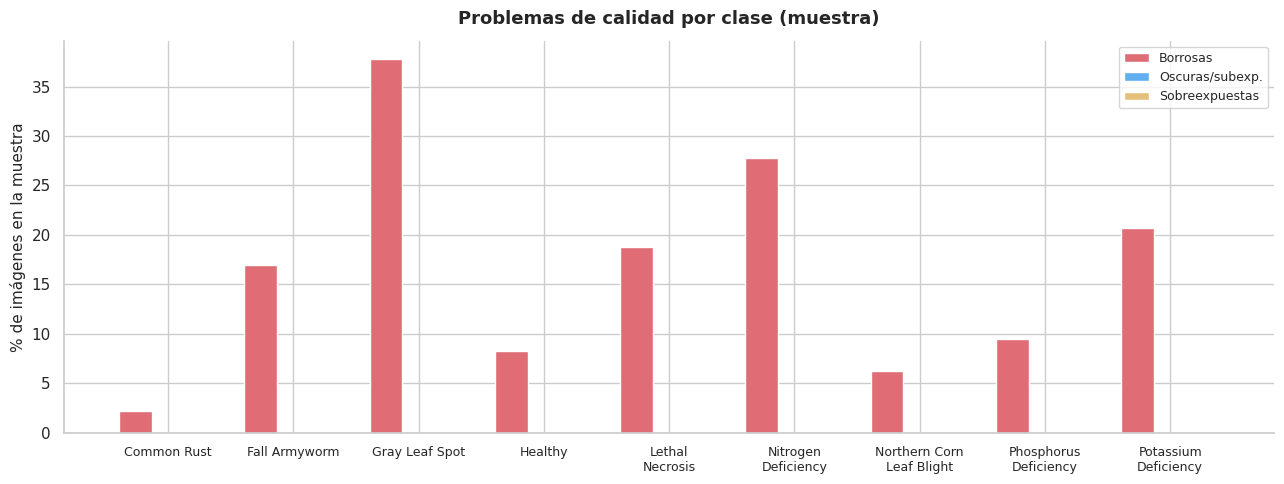

/tmp/ipykernel_378150/1143338503.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q, x="label", y="brightness", order=class_order,
/tmp/ipykernel_378150/1143338503.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q, x="label", y="blur_var", order=class_order,


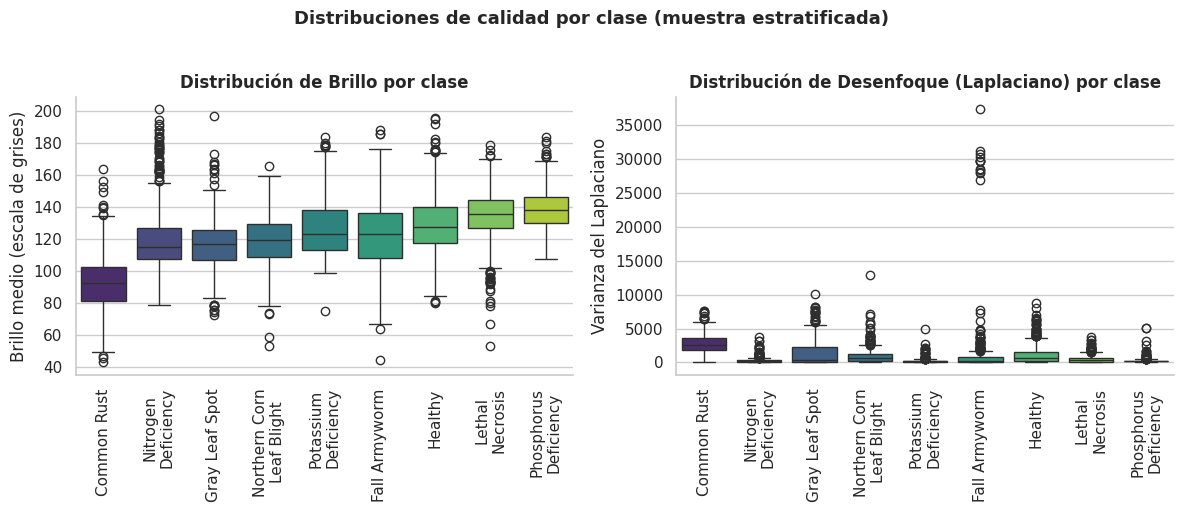

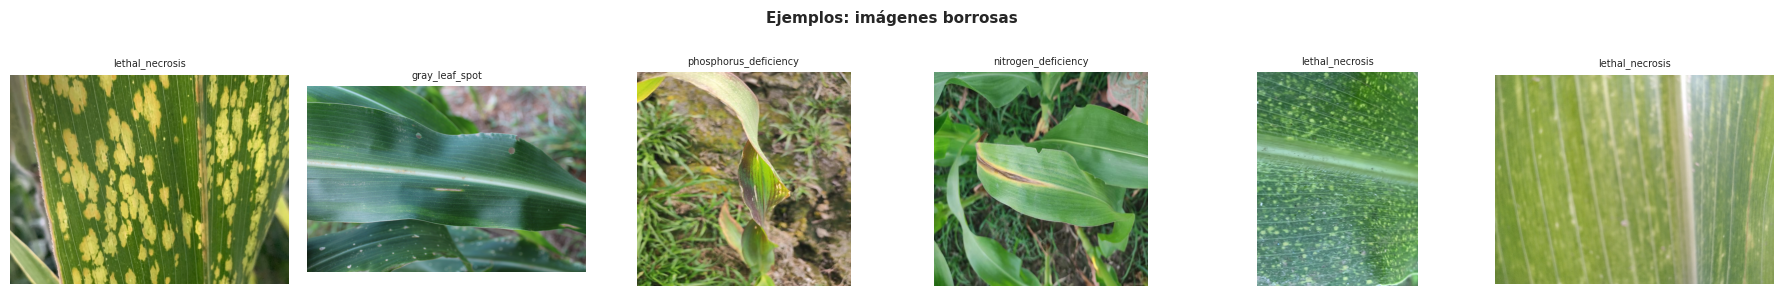

No se encontraron imágenes con: Ejemplos: imágenes oscuras / subexpuestas
No se encontraron imágenes con: Ejemplos: imágenes sobreexpuestas


In [6]:
BLUR_THRESHOLD    = 100.0
DARK_THRESHOLD    = 40.0
OVEREXP_THRESHOLD = 230.0

quality_records = []

for path in tqdm(sampled, desc="Analizando calidad"):
    try:
        img_bgr = cv2.imread(str(path))
        if img_bgr is None:
            continue
        gray       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blur_var   = cv2.Laplacian(gray, cv2.CV_64F).var()
        brightness = float(gray.mean())
        clase      = path.relative_to(CLEAN_DIR).parts[0]
        quality_records.append({
            "clase":      clase,
            "path":       str(path),
            "blur_var":   round(blur_var, 2),
            "brightness": round(brightness, 2),
            "is_blurry":  blur_var < BLUR_THRESHOLD,
            "is_dark":    brightness < DARK_THRESHOLD,
            "is_overexp": brightness > OVEREXP_THRESHOLD,
        })
    except Exception:
        pass

df_q = pd.DataFrame(quality_records)
print(f"Imágenes analizadas: {len(df_q):,}\n")
print("Resumen de problemas de calidad:")
print(f"  Borrosas       (blur_var < {BLUR_THRESHOLD}):   {df_q['is_blurry'].sum():,}  ({df_q['is_blurry'].mean()*100:.1f}%)")
print(f"  Oscuras/subexp (brightness < {DARK_THRESHOLD}): {df_q['is_dark'].sum():,}   ({df_q['is_dark'].mean()*100:.1f}%)")
print(f"  Sobreexpuestas (brightness > {OVEREXP_THRESHOLD}): {df_q['is_overexp'].sum():,}  ({df_q['is_overexp'].mean()*100:.1f}%)")

# Gráfico por clase: porcentaje de imágenes con problemas
quality_by_class = df_q.groupby("clase")[["is_blurry", "is_dark", "is_overexp"]].mean() * 100

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(quality_by_class))
w = 0.26
labels_q = [LABEL_MAP.get(c, c) for c in quality_by_class.index]

ax.bar(x - w,   quality_by_class["is_blurry"],  width=w, label="Borrosas",        color="#E06C75", edgecolor="white")
ax.bar(x,       quality_by_class["is_dark"],     width=w, label="Oscuras/subexp.", color="#61AFEF", edgecolor="white")
ax.bar(x + w,   quality_by_class["is_overexp"],  width=w, label="Sobreexpuestas",  color="#E5C07B", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels_q, fontsize=9)
ax.set_ylabel("% de imágenes en la muestra", fontsize=11)
ax.set_title("Problemas de calidad por clase (muestra)", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(TMP_DIR / "eda_04_calidad.png", dpi=150, bbox_inches="tight")
plt.show()

# Boxplots de distribución de brillo y desenfoque por clase
df_q["label"] = df_q["clase"].map(LABEL_MAP).fillna(df_q["clase"])
class_order = df_q.groupby("label")["brightness"].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_q, x="label", y="brightness", order=class_order,
            palette="viridis", ax=axes[0])
axes[0].set_title("Distribución de Brillo por clase", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Brillo medio (escala de grises)")
axes[0].tick_params(axis="x", rotation=90)
axes[0].spines[["top", "right"]].set_visible(False)

sns.boxplot(data=df_q, x="label", y="blur_var", order=class_order,
            palette="viridis", ax=axes[1])
axes[1].set_title("Distribución de Desenfoque (Laplaciano) por clase", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Varianza del Laplaciano")
axes[1].tick_params(axis="x", rotation=90)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Distribuciones de calidad por clase (muestra estratificada)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(TMP_DIR / "eda_04b_calidad_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Ejemplos visuales de imágenes con problemas
def show_flagged_examples(df_quality, flag_col, title, n=6):
    flagged = df_quality[df_quality[flag_col]]["path"].tolist()
    if not flagged:
        print(f"No se encontraron imágenes con: {title}")
        return
    sample = random.sample(flagged, min(n, len(flagged)))
    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    for ax, p in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(Path(p).relative_to(CLEAN_DIR).parts[0], fontsize=7)
        ax.axis("off")
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_flagged_examples(df_q, "is_blurry",  "Ejemplos: imágenes borrosas")
show_flagged_examples(df_q, "is_dark",    "Ejemplos: imágenes oscuras / subexpuestas")
show_flagged_examples(df_q, "is_overexp", "Ejemplos: imágenes sobreexpuestas")

---

## 1.6 Detección de duplicados y limpieza

Los duplicados fueron identificados y eliminados durante la etapa de limpieza del dataset utilizando **hash perceptual (pHash)** con la librería `imagededup` (threshold = 0, solo copias exactas a nivel perceptual). El proceso se ejecuta por clase completa (lab + real juntos) y los resultados se almacenan en el repositorio: `src/cleanup/results/`.

### Criterios de exclusión aplicados

Durante la revisión manual y automática se descartaron imágenes que presentaban alguna de las siguientes condiciones:

1. **Imágenes aumentadas** sin su original: datasets como `corn-leaf-diseases` solo publicaron versiones con augmentation (flip, rotación, brillo), haciendo imposible separar los originales.
2. **Metadatos inconsistentes o etiquetas erróneas:** imágenes etiquetadas con una clase pero con síntomas de otra (mezcla destructiva).
3. **Elementos fuera de clase:** presencia de tarjetas de identificación, marcadores de escala, objetos no relacionados con la hoja de maíz.
4. **Mezcla de entornos sin estructura recuperable:** datasets que combinaron lab y real sin naming convention consistente (ej. `multicrop-disease`).

### Data leakage entre datasets

Un hallazgo crítico fue la presencia de duplicados **entre datasets distintos**: varias imágenes de `maize_desease` y `multi_desease` son copias perceptuales idénticas de imágenes presentes en otras fuentes (principalmente `maize_africa` y `maize_field`). Incluir ambas versiones en train y val generaría *data leakage* directo, inflando artificialmente las métricas de validación.

### Resultados cuantitativos por fuente

| Fuente | Imágenes eliminadas (aprox.) |
|---|---:|
| `maize_desease` | ~6 508 |
| `multi_desease` | ~1 980 |
| `maize_africa` | ~51 |
| `maize_field` | ~23 |
| `cropdg` | ~1 |

> Total eliminado: **8 538 imágenes** en **8 050 grupos** de duplicados. El dataset actual en `data/clean/` es **post-deduplicación**.

In [ ]:
import csv
import json
import re
from collections import defaultdict

#  Configuración 
GDRIVE_RESULTS_FILE_ID = "1Erz4TivvmEJRr1LHwzqq8-UCFGc8BErB"

#  Localizar carpeta de resultados 
_REPO_RESULTS  = Path("../src/cleanup/results")
_COLAB_RESULTS = Path("/content/cleanup_results")

if _REPO_RESULTS.exists():
    RESULTS_DIR = _REPO_RESULTS
    print(f"Entorno: servidor/local (resultados en {RESULTS_DIR.resolve()})")
else:
    # Google Colab: descargar ZIP de resultados desde Drive
    import gdown, zipfile
    ZIP_R = Path("/content/cleanup_results.zip")
    if not _COLAB_RESULTS.exists():
        if not ZIP_R.exists():
            print("Descargando resultados de duplicados desde Drive...")
            gdown.download(id=GDRIVE_RESULTS_FILE_ID, output=str(ZIP_R), quiet=False)
        print("Descomprimiendo resultados...")
        with zipfile.ZipFile(ZIP_R, "r") as zf:
            zf.extractall("/content/cleanup_results")
        ZIP_R.unlink()
        print("Listo.")
    # El ZIP puede contener una subcarpeta (ej. results/) - buscar dónde están los CSVs
    csv_candidates = list(_COLAB_RESULTS.rglob("duplicates_*.csv"))
    RESULTS_DIR = csv_candidates[0].parent if csv_candidates else _COLAB_RESULTS
    print(f"Entorno: Google Colab (resultados en {RESULTS_DIR.resolve()})")

#  Fuentes conocidas del proyecto 
KNOWN_SOURCES = [
    "corn_leaf_roboflow", "maize_africa", "maize_desease", "maize_field",
    "cropdg", "maize_nutrient", "multi_desease",
]

def extract_source(filepath: str) -> str:
    name = Path(filepath).stem
    for src in sorted(KNOWN_SOURCES, key=len, reverse=True):
        if src in name:
            return src
    return "unknown"

def clase_from_filename(filename: str) -> str:
    stem = Path(filename).stem  # duplicates_CLASE_20260608_160954
    return re.sub(r"_\d{8}_\d{6}$", "", stem.replace("duplicates_", ""))

#  Procesar todos los CSVs 
dup_summary = defaultdict(lambda: {"groups": 0, "eliminated": 0, "by_source": defaultdict(int)})

csv_files = sorted(RESULTS_DIR.glob("duplicates_*.csv"))
print(f"\nArchivos CSV encontrados: {len(csv_files)}")

for csv_path in csv_files:
    clase = clase_from_filename(csv_path.name)
    with open(csv_path, newline="", encoding="utf-8") as fh:
        reader = csv.DictReader(fh)
        for row in reader:
            dups = json.loads(row["duplicate_paths"])
            dup_summary[clase]["groups"] += 1
            dup_summary[clase]["eliminated"] += len(dups)
            for dup_path in dups:
                src = extract_source(dup_path)
                dup_summary[clase]["by_source"][src] += 1

#  Tabla resumen 
df_dups = pd.DataFrame([
    {
        "clase":      clase,
        "grupos":     info["groups"],
        "eliminados": info["eliminated"],
        "fuentes":    ", ".join(f"{s}:{n}" for s, n in sorted(info["by_source"].items())),
    }
    for clase, info in sorted(dup_summary.items())
])

total_elim   = df_dups["eliminados"].sum()
total_grupos = df_dups["grupos"].sum()

print(f"\nTotal de grupos de duplicados detectados: {total_grupos:,}")
print(f"Total de imágenes eliminadas:             {total_elim:,}\n")
print(df_dups.to_string(index=False))

Entorno: servidor/local (resultados en /mnt/datasets/users/david/doctor-maiz/corn-leaf-desease-project/src/cleanup/results)

Archivos CSV encontrados: 8

Total de grupos de duplicados detectados: 8,050
Total de imágenes eliminadas:             8,538

                    clase  grupos  eliminados                                       fuentes
              common_rust     971        1048             maize_field:1, multi_desease:1047
            fall_armyworm     548         958            maize_africa:25, multi_desease:933
           gray_leaf_spot     535         535             maize_desease:513, maize_field:22
                  healthy    1773        1774 cropdg:1, maize_africa:26, maize_desease:1747
northern_corn_leaf_blight    4223        4223                            maize_desease:4223


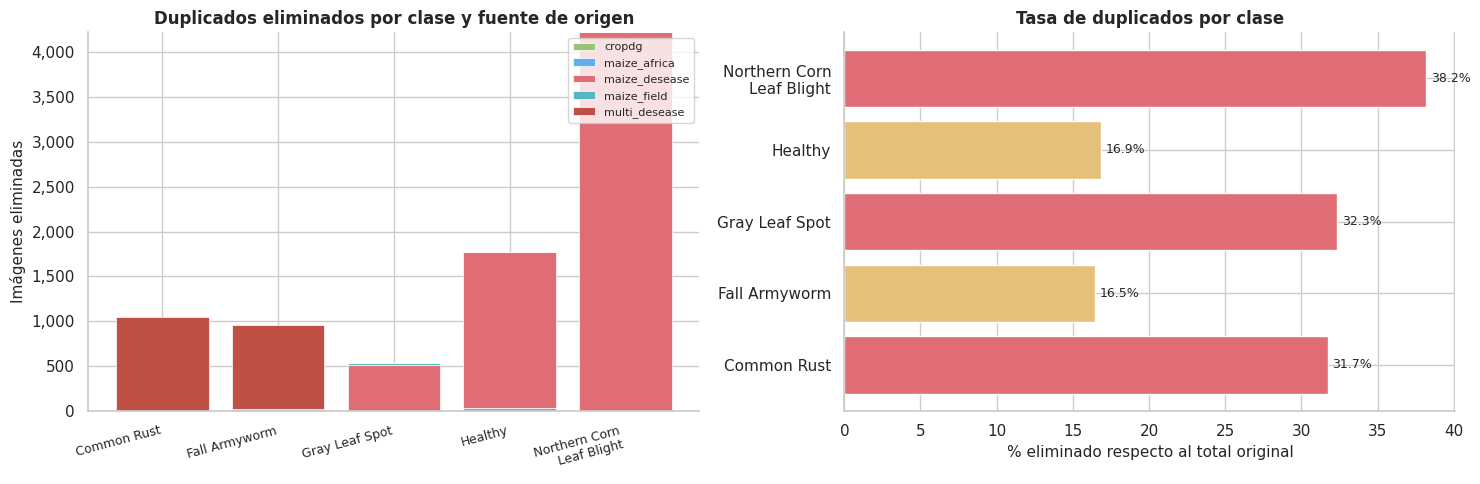


Método: pHash (imagededup), threshold=0 (solo copias exactas perceptualmente).
Total eliminado: 8,538 imágenes en 8,050 grupos.


In [8]:
#  Gráfico: duplicados eliminados por clase 
all_sources = sorted({src for info in dup_summary.values() for src in info["by_source"]})
clases_dup  = sorted(dup_summary.keys())

source_colors = {
    "maize_desease":  "#E06C75",
    "multi_desease":  "#BE5046",
    "maize_africa":   "#61AFEF",
    "maize_field":    "#56B6C2",
    "cropdg":         "#98C379",
    "corn_leaf_roboflow": "#E5C07B",
    "maize_nutrient": "#C678DD",
    "unknown":        "#ABB2BF",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Izquierda: barras apiladas por fuente
bottom = np.zeros(len(clases_dup))
x = np.arange(len(clases_dup))
for src in all_sources:
    vals = [dup_summary[c]["by_source"].get(src, 0) for c in clases_dup]
    axes[0].bar(x, vals, bottom=bottom, label=src,
                color=source_colors.get(src, "#ABB2BF"), edgecolor="white", linewidth=0.5)
    bottom += np.array(vals)

axes[0].set_xticks(x)
axes[0].set_xticklabels([LABEL_MAP.get(c, c) for c in clases_dup], fontsize=9, rotation=15, ha="right")
axes[0].set_ylabel("Imágenes eliminadas", fontsize=11)
axes[0].set_title("Duplicados eliminados por clase y fuente de origen", fontsize=12, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].legend(fontsize=8, loc="upper right")
axes[0].spines[["top", "right"]].set_visible(False)

# Derecha: % de duplicados respecto al total original (antes de limpiar)
df_pct = df.set_index("clase").reindex(clases_dup)
orig_totals = {
    c: df_pct.loc[c, "total"] + dup_summary[c]["eliminated"]
    for c in clases_dup if c in df_pct.index
}
pcts = [dup_summary[c]["eliminated"] / orig_totals[c] * 100 if c in orig_totals else 0
        for c in clases_dup]
bar_colors = ["#E06C75" if p > 30 else "#E5C07B" if p > 10 else "#70B77E" for p in pcts]
axes[1].barh([LABEL_MAP.get(c, c) for c in clases_dup], pcts, color=bar_colors, edgecolor="white")
axes[1].set_xlabel("% eliminado respecto al total original", fontsize=11)
axes[1].set_title("Tasa de duplicados por clase", fontsize=12, fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)
for i, p in enumerate(pcts):
    axes[1].text(p + 0.3, i, f"{p:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(TMP_DIR / "eda_05_duplicados.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMétodo: pHash (imagededup), threshold=0 (solo copias exactas perceptualmente).")
print(f"Total eliminado: {total_elim:,} imágenes en {total_grupos:,} grupos.")

---

## 1.7 Identificación de posibles sesgos

A partir de la distribución por clases y del análisis de origen (laboratorio vs campo), se identifican varios sesgos que pueden afectar el entrenamiento y la generalización del modelo.

### Tipos de sesgo identificados

1. **Desbalance de clases:** La clase `healthy` (8 744 imágenes) supera en más de **32.9×** a `potassium_deficiency` (266). Este desequilibrio obliga a usar estrategias como `class_weights='balanced'` o `WeightedRandomSampler` para que el modelo no ignore las clases minoritarias.

2. **Sesgo de entorno (lab vs campo):** `common_rust` tiene el **95.4 %** de sus imágenes tomadas en laboratorio (fondo blanco/negro uniforme). El modelo puede aprender el fondo en lugar de los síntomas, colapsando en condiciones de campo. Se recomienda augmentation con fondos aleatorios y ampliar las imágenes reales.

3. **Riesgo de dominio y sobreajuste a la fuente:** Clases como `northern_corn_leaf_blight` concentran la mayoría de imágenes reales en un único dataset geográfico (`maize_africa`). Esto limita la variabilidad de condiciones de luz, suelo y clima, aumentando el riesgo de sobreajuste a ese dominio específico.

4. **Heterogeneidad visual intraclase en `fall_armyworm`:** Las imágenes de esta clase no son visualmente homogéneas - mezclan dos señales distintas según la fuente de origen: (a) **hoja con daño foliar** sin insecto visible (`corn_leaf_roboflow`, `maize_africa/Maize Fall Army Worm Activity`), y (b) **hoja con daño y gusano** visible (`maize_africa/Maize Fall Army Worm Pest`, `multicrop`). Esto introduce ambigüedad en lo que el modelo aprende como señal diagnóstica de la clase.

5. **Sesgo visual por elementos externos:** Algunos subsets incluyen tarjetas de identificación, marcadores de escala o fondos con objetos no relacionados (ej. Roboflow). Estos elementos pueden convertirse en *shortcuts* si aparecen de forma sistemática en una clase.

6. **Implicaciones prácticas para el entrenamiento:**
   - Priorizar imágenes de campo (`real/`) sobre las de laboratorio en la división de validación, para medir la generalización real del modelo.
   - Para `common_rust`, se recomienda alcanzar al menos **2 000 imágenes de campo** antes de entrenar (actualmente solo 106).
   - Las deficiencias nutricionales (`nitrogen`, `phosphorus`, `potassium`) provienen de una única fuente con resolución fija 640×640; considerar nuevas fuentes antes de escalar el modelo.

In [ ]:
biases = [
    {
        "clase":   "common_rust",
        "sesgo":   "Dominio de imágenes de laboratorio (95.4%)",
        "detalle": (
            "2,150 de 2,256 imágenes provienen de entorno controlado (PlantVillage via cropdg y maize_desease). "
            "El modelo podría aprender el fondo uniforme negro/blanco en lugar de los síntomas foliares reales. "
            "Solo 106 imágenes en campo."
        ),
        "riesgo": "Alto",
    },
    {
        "clase":   "gray_leaf_spot",
        "sesgo":   "Mezcla lab/real casi pareja, pero fuentes limitadas",
        "detalle": (
            "513 lab (todas de PlantVillage/cropdg) y 606 real (todas de maize_field). "
            "Poca variedad de fuentes para el entorno real."
        ),
        "riesgo": "Medio",
    },
    {
        "clase":   "northern_corn_leaf_blight",
        "sesgo":   "Alta proporción real, pero dominada por una sola fuente",
        "detalle": (
            "5,942 imágenes reales, de las cuales ~4,223 originalmente provenían de maize_africa (eliminados como duplicados). "
            "La representación geográfica podría ser limitada a condiciones de África subsahariana."
        ),
        "riesgo": "Medio",
    },
    {
        "clase":   "fall_armyworm",
        "sesgo":   "Heterogeneidad visual intraclase: daño vs. daño + gusano",
        "detalle": (
            "Las imágenes mezclan dos señales visuales distintas según la fuente: (1) hoja con daño foliar "
            "sin insecto visible (corn_leaf_roboflow y maize_africa/Activity), y (2) hoja con daño y gusano "
            "visible (maize_africa/Pest y multicrop). El modelo puede aprender atajos de textura del insecto "
            "en lugar del patrón de daño foliar, o fallar cuando el gusano no está presente."
        ),
        "riesgo": "Medio-Alto",
    },
    {
        "clase":   "deficiencias nutricionales",
        "sesgo":   "Fuente única y baja representación",
        "detalle": (
            "Nitrogen (523), Phosphorus (612) y Potassium (266) provienen exclusivamente de maize_nutrient. "
            "Todas en entorno real con resolución fija 640×640. Potassium especialmente escaso (32.9x vs healthy)."
        ),
        "riesgo": "Medio-Alto",
    },
]

print(f"{'CLASE':<35} {'RIESGO':<12} {'DESCRIPCIÓN'}")
print("-" * 100)
for b in biases:
    print(f"{b['clase']:<35} {b['riesgo']:<12} {b['sesgo']}")
    print(f"  - {b['detalle'][:110]}...")
    print()

# Visualización: composición lab/real + ratio de desbalance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_plot = df.set_index("label")[["lab", "real"]]
df_plot.plot(kind="barh", stacked=True, ax=axes[0],
             color=["#5B8DB8", "#70B77E"], edgecolor="white")
axes[0].set_title("Composición lab vs real por clase", fontweight="bold")
axes[0].set_xlabel("Número de imágenes")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()

ratio = df["total"].max() / df["total"]
ratio_df = pd.DataFrame({"label": df["label"], "ratio": ratio})
colors_r = ["#E06C75" if r > 10 else "#E5C07B" if r > 5 else "#70B77E"
            for r in ratio_df["ratio"]]
axes[1].barh(ratio_df["label"], ratio_df["ratio"], color=colors_r, edgecolor="white")
axes[1].axvline(1, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("Desbalance relativo (ratio respecto a clase mayor)", fontweight="bold")
axes[1].set_xlabel("Ratio (clase_mayor / clase_i)")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(TMP_DIR / "eda_06_sesgos.png", dpi=150, bbox_inches="tight")
plt.show()

max_idx = ratio.idxmax()
min_idx = ratio.idxmin()
print(f"\nRatio de desbalance máximo: {ratio.max():.1f}x  ({df.loc[max_idx, 'clase']!r} vs {df.loc[min_idx, 'clase']!r})")

---

## Conclusiones

1. **Desbalance severo:** La clase `healthy` (8 744) triplica a `northern_corn_leaf_blight` (6 830) y supera en **~32.9×** a `potassium_deficiency` (266). Esto requiere muestreo ponderado o un techo máximo por clase durante el entrenamiento.

2. **Sesgo de dominio en `common_rust`:** El 95.4 % de las imágenes proviene de entorno controlado (fondo uniforme). El modelo podría aprender el fondo y no los síntomas. Se recomienda data augmentation agresivo (fondos aleatorios, variación de iluminación) y ampliar las imágenes de campo.

3. **Resolución heterogénea:** El dataset mezcla imágenes con resoluciones muy dispares. Las de `corn_leaf_roboflow` ya vienen fijas a 640×640 px. El pipeline de entrenamiento debe aplicar redimensionamiento consistente a la resolución de entrada del modelo.

4. **Duplicados controlados (8 538 eliminadas):** Se eliminaron **8 538 imágenes** agrupadas en **8 050 grupos** detectados por pHash. Las principales fuentes de duplicados fueron `maize_desease` (6 508), `multi_desease` (1 980) y `maize_africa` (51). El dataset actual en `data/clean/` es post-deduplicación, minimizando el riesgo de data leakage.

5. **Fuentes limitadas en clases pequeñas:** `potassium_deficiency`, `nitrogen_deficiency` y `phosphorus_deficiency` tienen una sola fuente de origen (`maize_nutrient`), lo que reduce la diversidad de condiciones de captura y aumenta el riesgo de sobreajuste a patrones específicos.
